# 

# Titanic Exploratory Data Analytics (EDA)

This project analyzes passengers survival patterns using the Titanic dataset.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv


In [2]:
import os 
os.listdir('/kaggle/input')

['datasets']

In [3]:
import os 

os.listdir('/kaggle/input/datasets')

['heptapod']

In [4]:
import os 

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/heptapod
/kaggle/input/datasets/heptapod/titanic


In [5]:
import os 
os.listdir('/kaggle/input/datasets/heptapod/titanic')

['train_and_test2.csv']

In [6]:
import os 
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv


In [7]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv')
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [8]:
df.shape

(1309, 28)

In [9]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [11]:
df['zero'].value_counts()
df['zero.1'].value_counts()

zero.1
0    1309
Name: count, dtype: int64

In [12]:
df['2urvived'].value_counts()

2urvived
0    967
1    342
Name: count, dtype: int64

In [13]:
df['2urvived'].value_counts(normalize=True) * 100

2urvived
0    73.873186
1    26.126814
Name: proportion, dtype: float64

In [14]:
df.groupby('Sex')['2urvived'].mean() * 100

Sex
0    12.930012
1    50.000000
Name: 2urvived, dtype: float64

Finding #3
Survival rate differs significantly by gender.

sex = 1 : 50.0%
sex = 0 : 12.93%

Gender appears to be an important factor in survival.

In [15]:
df.groupby('Pclass')['2urvived'].mean() * 100

Pclass
1    42.105263
2    31.407942
3    16.784203
Name: 2urvived, dtype: float64

Finding #4
passenger class strongly affects survival.

1st Class: ~42%
2nd Class: ~31%
3rd Class: ~16%

passengers in higher classes had a better chance of survival.


<Axes: >

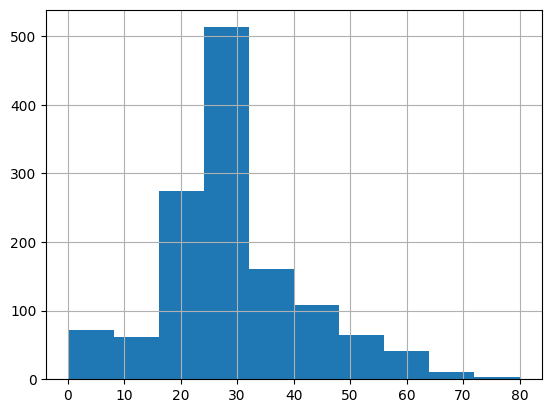

In [16]:
df['Age'].describe()

df['Age'].hist()

In [17]:
df.groupby('2urvived')['Age'].mean()

2urvived
0    29.931748
1    28.291433
Name: Age, dtype: float64

Finding #5
Average passenger age = 29.5 years.

Most passengers appear to be young adults

Age ranges form 0.17 years to 80 years.

In [18]:
df.groupby('sibsp')['2urvived'].mean() * 100

sibsp
0    23.569024
1    35.109718
2    30.952381
3    20.000000
4    13.636364
5     0.000000
8     0.000000
Name: 2urvived, dtype: float64

Finding #6:
passengers travelling with 1 siblings/ spouse had the highest survival rate (~35%).

very large families had poor survival rates.

In [19]:
df.corr(numeric_only=True)['2urvived'].sort_values(ascending=False)

2urvived       1.000000
Sex            0.404020
Fare           0.173786
Parch          0.054908
sibsp         -0.014375
Age           -0.055862
Embarked      -0.093225
Pclass        -0.244686
Passengerid   -0.331493
zero                NaN
zero.1              NaN
zero.2              NaN
zero.3              NaN
zero.4              NaN
zero.5              NaN
zero.6              NaN
zero.7              NaN
zero.8              NaN
zero.9              NaN
zero.10             NaN
zero.11             NaN
zero.12             NaN
zero.13             NaN
zero.14             NaN
zero.15             NaN
zero.16             NaN
zero.17             NaN
zero.18             NaN
Name: 2urvived, dtype: float64

In [20]:
df.shape

(1309, 28)

In [21]:
df.nunique()

Passengerid    1309
Age              98
Fare            281
Sex               2
sibsp             7
zero              1
zero.1            1
zero.2            1
zero.3            1
zero.4            1
zero.5            1
zero.6            1
Parch             8
zero.7            1
zero.8            1
zero.9            1
zero.10           1
zero.11           1
zero.12           1
zero.13           1
zero.14           1
Pclass            3
zero.15           1
zero.16           1
Embarked          3
zero.17           1
zero.18           1
2urvived          2
dtype: int64

In [22]:
cols_to_drop = [col for col in df.columns if 'zero' in col]
df = df.drop(columns=cols_to_drop)

In [23]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [24]:
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
2urvived       0
dtype: int64

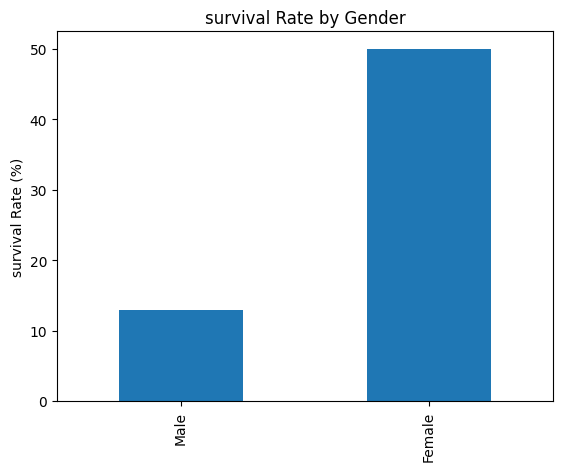

In [25]:
survival_by_gender = df.groupby('Sex')['2urvived'].mean() * 100
survival_by_gender.index = ['Male', 'Female']

survival_by_gender.plot(kind='bar')
plt.title('survival Rate by Gender')
plt.ylabel('survival Rate (%)')
plt.show()

Observation:

Female passengers had a significantly higher survival rate (50%)
compared to Male passengers (~13%).

This indicates that gender was one the strongest factors in the Titanic dataset.

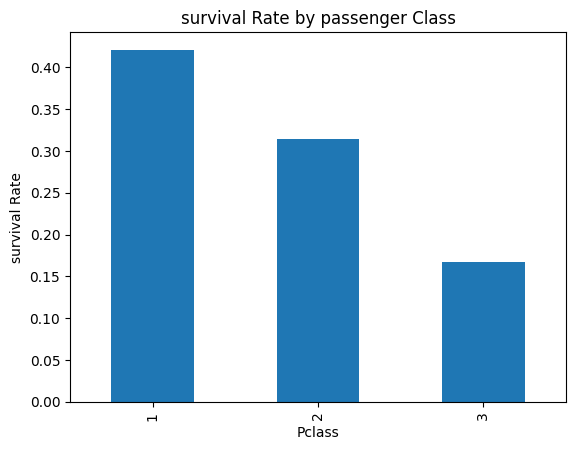

In [26]:
df.groupby('Pclass')['2urvived'].mean().plot(kind='bar')
plt.title('survival Rate by passenger Class')
plt.ylabel('survival Rate')
plt.show()

## Obsrvation 

The survival rate varid significantly across passenger classes.

- First-class passengers had the highest survival rate (~42%).
- second-class passengers had a moderate survival rate (~31%).
- Third-class passengers had the lowest survival rate (~16%).

This suggests that passenger class was an important factor influencing survival. passengers travelling in higher classes were more likely to survive than those in lower classes.

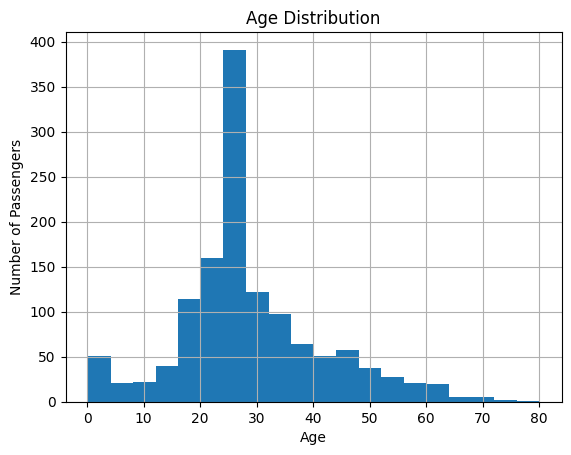

In [27]:
df['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

Most passenger were between 20 and 35 years old.

The titanic passenger population was mainly composed of young adults, with fewer children and elderly passengers.

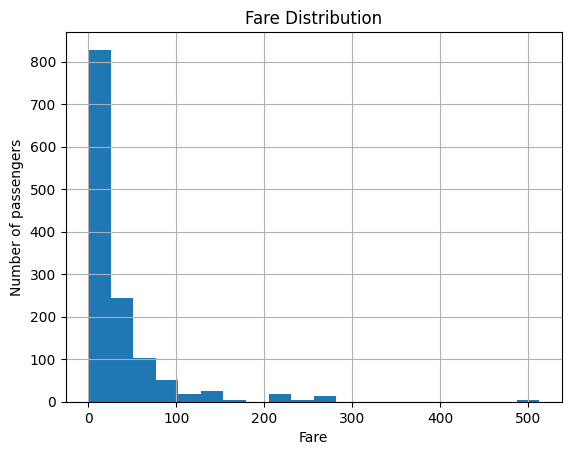

In [28]:
df['Fare'].hist(bins=20)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of passengers')
plt.show()

Titanic Data Analysis

Dataset size: 1309 rows

key Findings:
1. Survival Rate = 26.13%
2. Gender is the strongest factor affecting survival.
3. First-class passengers survived more often.
4. Age has a weak realtionship with survival.
5. Large families had lower survival rates.
6. several constant-value columns were removed during data cleaning.

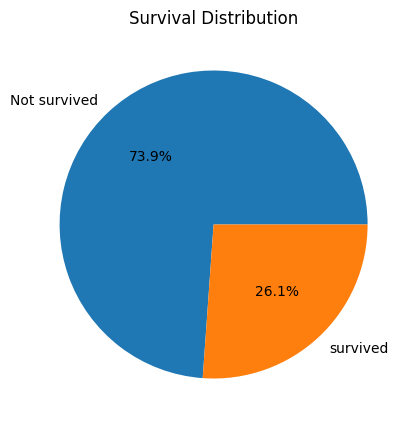

In [29]:
survival_counts = df['2urvived'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(survival_counts, labels=['Not survived', 'survived'], autopct='%1.1f%%')

plt.title('Survival Distribution')
plt.show()

** About 74% of passengers did not survive, while 26% survived.

** The survival rate on the Titanic was relatively low.

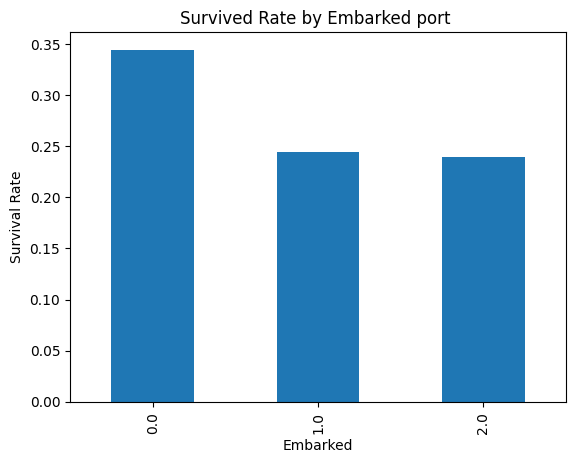

In [30]:
df.groupby('Embarked')['2urvived'].mean().plot(kind='bar')
plt.title('Survived Rate by Embarked port ')
plt.ylabel('Survival Rate')
plt.show()

## Survival by Embarked port 

survival rate varied across embarkation ports.

The boarding location may have influenced passenger survival.

In [31]:
Family_size = df['sibsp'] + df['Parch']
Family_size.groupby(df['2urvived']).mean()

2urvived
0    0.864529
1    0.938596
dtype: float64

## sibsp Analysis

passengers travelling with 1 family member had a higher survival rate than those travelling alone or in very large groups.

samll family groups had a better chances of survival.

# key insights

- Females had a much higher survival rate than males.
- First-class passengers survived more often than third-class passengers.
- Most passengers were young adults.
- Higher fares were associated with better suvival chances.
- Overall survival rate was only 26%.